<a href="https://colab.research.google.com/github/eojin22/ESAA/blob/main/OB_WEEK01_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 텍스트 분석

- **NLP**
  - 머신이 인간의 언어를 이해하고 해석하는 데 더 중점

- **텍스트 마이닝**
  - 비정형 텍스트에서 의미있는 정보를 추출하는 것에 더 중점

## 텍스트 분석 이해

머신러닝 알고리즘은 숫자형의 피처 기반 데이터만 입력받을 수 있기 때문에 텍스트를 머신러닝에 적용하기 위해서는 비정형 텍스트 데이터를 어떻게 피처 형태로 추출하고 추출된 피처에 의미 있는 값을 부여하는가 하는 것이 매우 중요한 요소

### 텍스트 분석 수행 프로세스
**1. 텍스트 사전 준비작업(텍스트 전처리)**
- 텍스트를 피처로 만들기 전에 미리 클렌징, 대/소문자 변경, 특수문자 삭제 등의 클렌징 작업
- 단어(Word) 등의 토큰화 작업, 의미 없는 단어(Stop word) 제거 작업, 어근 추출(Stemming/Lemmatization) 등의 텍스트 정규화 작업을 수행하는 것을 통칭

**2. 피처 벡터화/추출**
- 사전 준비 작업으로 가공된 텍스트에서 피처를 추출하고 여기에 벡터 값을 할당
- 대표적인 방법은 BOW와 Word2Vec이 있으며, BOW는 대표적으로 Count 기반과 TF-IDF 기반 벡터화가 있음

**3. ML 모델 수립 및 학습/예측/평가**
- 피처 벡터화된 데이터 세트에 ML 모델을 적용해 학습/예측 및 평가를 수행


### 파이썬 기반의 NLP, 텍스트 분석 패키지

**NLTK (Natural Language Toolkit for Python)**
- 파이썬의 가장 대표적인 NLP 패키지
-  방대한 데이터 세트와 서브 모듈을 가지고 있으며 NLP의 거의 모든 영역을 커버하고 있음
-  많은 NLP 패키지가 NLTK의 영향을 받아 작성되고 있음
-  수행 속도 측면에서 아쉬운 부분이 있어서 실제 대량의 데이터 기반에서는 제대로 활용되지 못히고 있음

**Gensim**
- 토픽 모델링 분야에서 가장 두각을 나타내는 패키지
- 오래전부터 토픽 모델링을 쉽게 구현할 수 있는 가능을 제공해 왔으며, Word2Vec 구현 등의 다양한 신기능도 제공
- SpaCy와 함께 가장 많이 사용되는 NLP 패키지

**SpaCy**
- 뛰어난 수행 성능으로 최근 가장 주목을 받는 NLP 패키지



---



## 텍스트 사전 준비 작업(텍스트 전처리) - 텍스트 정규화

**텍스트 정규화 :** 머신러닝 알고리즘이나 NLP 앱에 입력 데이터로 사용하기 위해 클렌징, 정제, 토큰화, 어근화 등의 다양한 텍스트 데이터의 사전 작업을 수행하는 것

- 클렌징 (Cleansing)
- 토큰화(Tokenization)
- 필터링/스톱워드제거/철자수정
- Stemming
- Lemmatization

### 클렌징
- 텍스트에서 분석에 오히려 방해가 되는 불필요한 문자, 기호 등을 사전에 제거하는 작업
- HTML, XML 태그나 특정 기호 등을 사전에 제거

###  텍스트 토큰화
- 문서에서 문장을 분리하는 문장 토큰화
- 문장에서 단어를 토큰으로 분리하는 단어 토큰화

**문장 토큰화** : 문장의 마침표(.), 개행문자(\n) 등 문장의 마지막을 뜻하는 기호에 따라 분리.

아래 코드는 NLTK에서 일반적으로 많이 쓰이는 sent_tokenize를 이용해 토큰화 수행

In [1]:
from nltk import sent_tokenize
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

text_sample = 'The Matrix is everywhere its all around us, here even in this room. \
You can see it out your window or on your television. \
You feel it when you go to work, or go to church or pay your taxes.'
sentences = sent_tokenize(text=text_sample)

print(type(sentences), len(sentences))
print(sentences)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


<class 'list'> 3
['The Matrix is everywhere its all around us, here even in this room.', 'You can see it out your window or on your television.', 'You feel it when you go to work, or go to church or pay your taxes.']


- sent_tokenize()가 반환하는 것은 각각의 문장으로 구성된 list 객체
- 반환된 list 객체가 3개의 문장으로 된 문자열을 가지고 있는 것을 알 수 있음

**단어 토큰화**

- 문장을 단어로 토큰화하는 것
- 공백, 콤마(,), 마침표(.), 개행문자 등으로 단어를 분리하지만, 정규 표현식을 이용해 다양한 유형으로 토큰화를 수행
- 마침표(.)나 개행문자와 같이 문장을 분리하는 구분자를 이용해 단어를 토큰화할 수 있기에 Bag of Word와 같이 단어의 순서가 중요하지 않은 경우, 문장 토큰화를 사용하지 않고 단어 토큰화만 사용해도 충분
- 일반적으로 문장 토큰화는 각 문장이 가지는 시맨틱적인 의미가 중요한 요소로 사용될 때 사용

아래 코드로 NTLK에서 기본으로 제공하는 word_tokenize()를 이용해 단어로 토큰화

In [2]:
from nltk import word_tokenize

sentence = "The Matrix is everywhere its all around us, here even in this room."
words = word_tokenize(sentence)
print(type(words), len(words))
print(words)

<class 'list'> 15
['The', 'Matrix', 'is', 'everywhere', 'its', 'all', 'around', 'us', ',', 'here', 'even', 'in', 'this', 'room', '.']


In [3]:
from nltk import word_tokenize, sent_tokenize

# 여러개의 문장으로 된 입력 데이터를 문장별로 단어 토크화하게 만드는 함수 생성
def tokenize_text(text):

  # 문장별로 분리 토큰
  sentences = sent_tokenize(text)
  # 분리된 문장별 단어 토큰화
  word_tokens = [word_tokenize(sentence) for sentence in sentences]
  return word_tokens

# 여러 문장에 대해 문장별 단어 토큰화 수행.
word_tokens = tokenize_text(text_sample)
print(type(word_tokens),len(word_tokens))
print(word_tokens)

<class 'list'> 3
[['The', 'Matrix', 'is', 'everywhere', 'its', 'all', 'around', 'us', ',', 'here', 'even', 'in', 'this', 'room', '.'], ['You', 'can', 'see', 'it', 'out', 'your', 'window', 'or', 'on', 'your', 'television', '.'], ['You', 'feel', 'it', 'when', 'you', 'go', 'to', 'work', ',', 'or', 'go', 'to', 'church', 'or', 'pay', 'your', 'taxes', '.']]


### 스톱 워드 제거
**스톱 워드**
- 분석에 큰 의미가 없는 단어를 지칭. is, the, a, will 등 문장을 구성하는 필수 문법 요소지만 문맥적으로 큰 의미가 없는 단어가 이에 해당
- 언어별로 이러한 스톱 워드가 목록화돼 있음
- NLTK의 경우 가장 다양한 언어의 스톱 워드를 제공

In [4]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [5]:
print('영어 stop words 갯수:',len(nltk.corpus.stopwords.words('english')))
print(nltk.corpus.stopwords.words('english')[:20])

영어 stop words 갯수: 198
['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been']


In [6]:
import nltk

stopwords = nltk.corpus.stopwords.words('english')
all_tokens = []
# 위 예제에서 3개의 문장별로 얻은 word_tokens list에 대해 스톱 워드를 제거하는 반복문
for sentence in word_tokens:
  filtered_words=[]
  # 개별 문장별로 토큰화된 문장 list에 대해 스톱 워드를 제거하는 반복문
  for word in sentence:
    # 소문자로 모두 반환합니다.
    word = word.lower()
    # 토큰화된 개별 단어가 스톱 워드의 단어에 포함되지 않으면 word_tokens에 추가
    if word not in stopwords:
        filtered_words.append(word)
  all_tokens.append(filtered_words)

print(all_tokens)

[['matrix', 'everywhere', 'around', 'us', ',', 'even', 'room', '.'], ['see', 'window', 'television', '.'], ['feel', 'go', 'work', ',', 'go', 'church', 'pay', 'taxes', '.']]


### Stemming과 Lemmatization
- 문법적 또는 의미적으로 변화하는 단어의 원형을 찾는 것

- Lemmatization이 Stemming보다 정교하며 의미론적인 기반에서 단어의 원형을 찾음

- Lemmatization이 Stemming보다 변환에 더 오랜 시간을 필요로 함

- NLTK는 다양한 Stemmer를 제공하며 대표적으로 Porter, Lancaster, Snowball Stemmer가 있음

- Lemmatization을 위해서는 WordNetLemmatizer를 제공

In [7]:
from nltk.stem import LancasterStemmer
stemmer = LancasterStemmer()

print(stemmer.stem('working'), stemmer.stem('works'), stemmer.stem('worked'))
print(stemmer.stem('amusing'), stemmer.stem('amuses'), stemmer.stem('amused'))
print(stemmer.stem('happier'), stemmer.stem('happiest'))
print(stemmer.stem('fancier'), stemmer.stem('fanciest'))

work work work
amus amus amus
happy happiest
fant fanciest


- 단순 변화는 원형 단어 제대로 인식하지만 아닌 경우나 비교급 형태는 잘 인식하지 못함.
- WordNetLemmatizer를 이용해 Lemmatization수행 : 단어의 품사 입력해줘야함

In [8]:
from nltk.stem import WordNetLemmatizer
import nltk
nltk.download('wordnet')

lemma = WordNetLemmatizer()
print(lemma.lemmatize('amusing', 'v'), lemma.lemmatize('amuses', 'v'), lemma.lemmatize('amused', 'v'))
print(lemma.lemmatize('happier', 'a'), lemma.lemmatize('happiest', 'a'))
print(lemma.lemmatize('fancier', 'a'), lemma.lemmatize('fanciest', 'a'))

[nltk_data] Downloading package wordnet to /root/nltk_data...


amuse amuse amuse
happy happy
fancy fancy




---



## Bag of Words - BOW
- Bag of Words 모델은 문서가 가지는 모든 단어(Words)를 문맥이나 순서를 무시하고 일괄적으로 단 어에 대해 빈도 값을 부여해 피처 값을 추출하는 모델

- 장점: 쉽고 빠른 구축
- 단점
  1. 문맥 의미(Semantic Context) 반영 부족
  2. 희소 행렬 문제(희소성, 희소 행렬)
    



### BOW 피처 벡터화
머신러닝 알고리즘은 일반적으로 숫자형 피처를 데이터로 입력받아 동작하기에 텍스트와 같은 데이터는 머신러닝 알고리즘에 바로 입력 불가 => 따라서 텍스트는 특정 의미를 가지는 숫자형 값인 벡터 값으로 변환해야 함

- **카운트 기반의 벡터화:** 단어 피처에 값을 부여할 때 각 문서에서 해당 단어가 나타나는 횟수, 즉 Count를 부여하는 경우. 그 문서의 특징을 나타내기보다는 언어의 특성상 문장에서 자주 사용 될 수밖에 없는 단어까지 높은 값을 부여

- **TF—IDF :** 개별 문서에서 자주 나타나는 단어에 높은 가중치를 주되, 노든 문서에서 전반적으로 자주 나타나는 단어에 대해서는 페널 티를 주는 방식으로 값을 부여

### 사이킷런의 Count 및 TF-IDF 벡터화 구현: CountVectorizer, TfidfVectorizer

- 사이킷런의 CountVectorizer 클래스는 카운트 기반의 벡터화를 구현한 클래스
- CountVectorizer 클래스는 단지 피처 벡터화만 수행하지는 않으며 소문자 일괄 변환, 토큰화, 스톱 워 드 필터링 등의 텍스트 전처리도 함께 수행

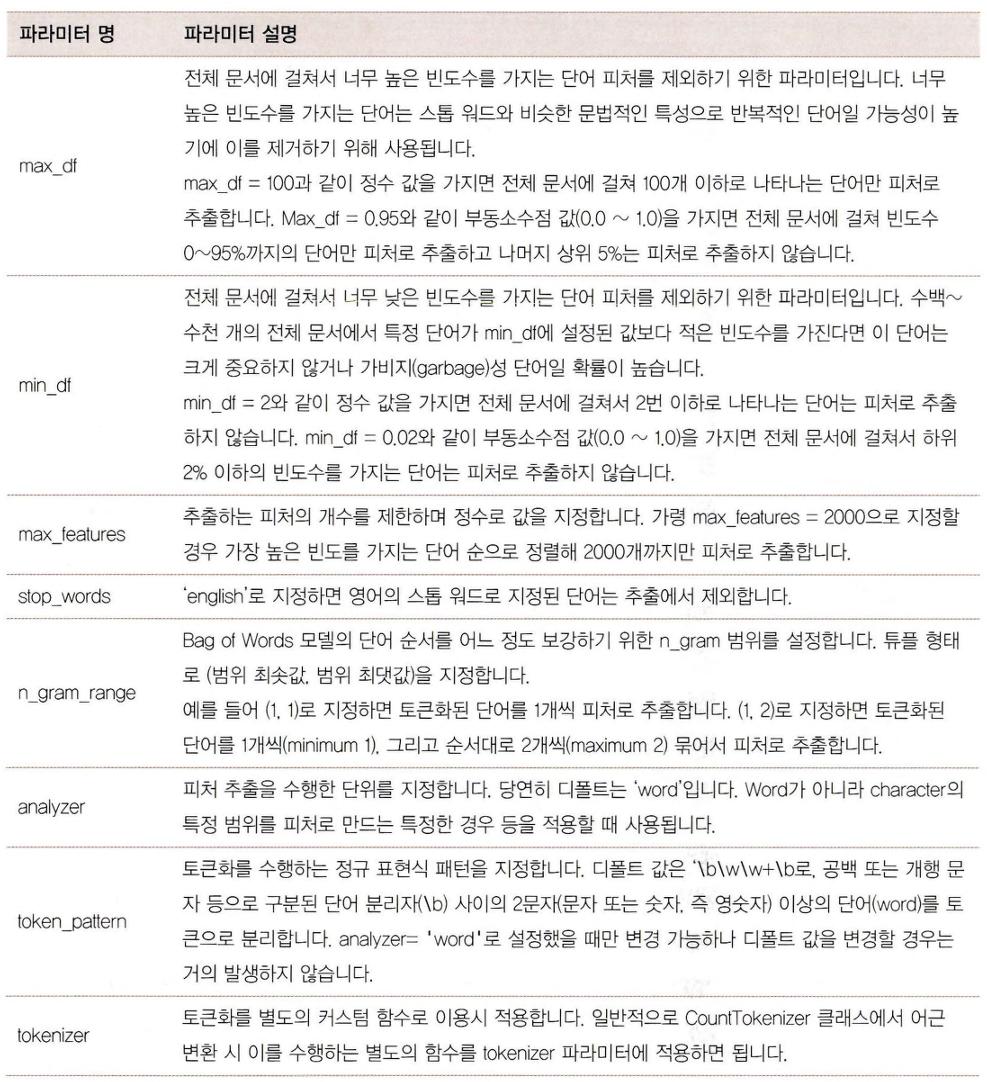

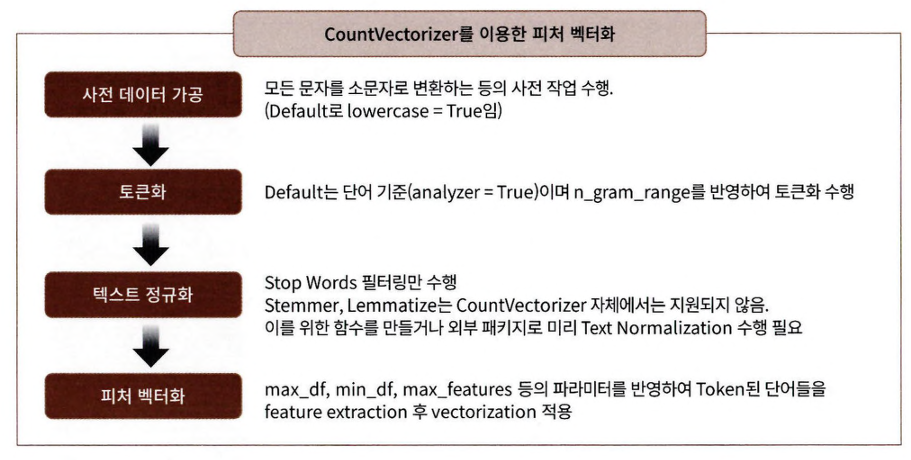

### BOW 벡터화를 위한 희소 행렬
- 희소행렬: 대규모 행렬의 대부분의 값을 0이 차지하는 행렬
-> 희소 행렬을 물리적으로 적은 메모리 공간을 차지할 수 있도록 변환

<해결방법>

**1. 희소 행렬 — COO 형식**
- COO(Coordinate : 좌표) 형식은 0이 아닌 데이터만 별도의 데이터 배열에 저장하고, 그 데이터가 가리키는 행과 열의 위치를 별도의 배열로 저장하는 방식

**2. 희소 행렬 - CSR 형식**
- CSR(Compressed Sparse Row) 형식은 COO 형식이 행과 열의 위치를 나타내기 위해서 반복적인 위치 데이터를 사용해야 하는 문제점을 해결한 방식



### 희소 행렬 — COO 형식

In [9]:
import numpy as np

dense = np.array( [[3,0,1], [0,2,0]])

In [10]:
from scipy import sparse

# 0이 아닌 데이터 추출
data = np.array([3,1,2])

# 행 위치와 열 위치를 각각 배열로 생성
row_pos = np.array([0,0,1])
col_pos = np.array([0,2,1])

# sparse 패키지의 coo_matrix를 이용해 COO 형식으로 희소 행렬 생성
sparse_coo = sparse.coo_matrix((data, (row_pos, col_pos)))

In [11]:
sparse_coo.toarray()

array([[3, 0, 1],
       [0, 2, 0]])

### 희소 행렬 - CSR 형식

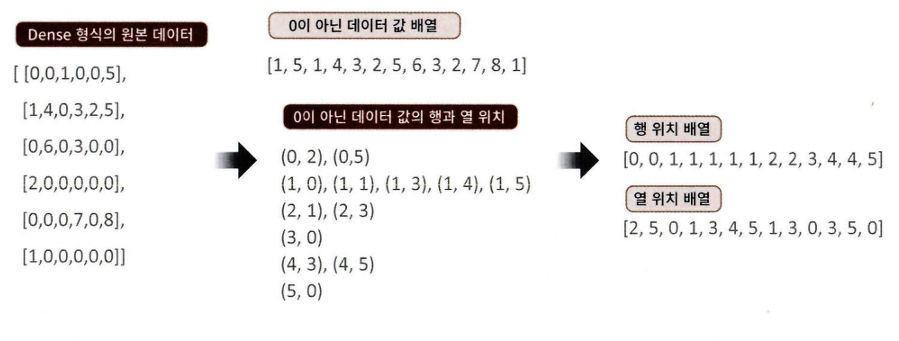

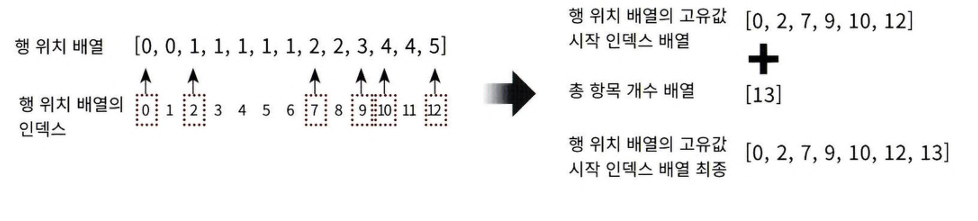

In [12]:
[ [0, 0, 1, 0, 0, 5], [1, 4, 0, 3, 2, 5], [0, 6, 0, 3, 0, 0], [2, 0, 0, 0, 0, 0], [0, 0, 0, 7, 0, 8], [1, 0, 0, 0, 0, 0] ]

[[0, 0, 1, 0, 0, 5],
 [1, 4, 0, 3, 2, 5],
 [0, 6, 0, 3, 0, 0],
 [2, 0, 0, 0, 0, 0],
 [0, 0, 0, 7, 0, 8],
 [1, 0, 0, 0, 0, 0]]

In [13]:
from scipy import sparse

dense2 = np.array([[0, 0, 1, 0, 0, 5],
                   [1, 4, 0, 3, 2, 5],
                   [0, 6, 0, 3, 0, 0],
                   [2, 0, 0, 0, 0, 0],
                   [0, 0, 0, 7, 0, 8],
                   [1, 0, 0, 0, 0, 0]])

# 0이 아닌 데이터 추출
data2 = np.array([1, 5, 1, 4, 3, 2, 5, 6, 3, 2, 7, 8, 1 ])

# 행 위치와 열 위치를 각각 array로 생성
row_pos = np.array([0, 0, 1, 1, 1, 1, 1, 2, 2, 3, 4, 4, 5])
col_pos = np.array([2, 5, 0, 1, 3, 4, 5, 1, 3, 0, 3, 5, 0])

# COO 형식으로 변환
sparse_coo = sparse.coo_matrix((data2, (row_pos, col_pos)))

# 행 위치 배열의 고유한 값의 시작 위치 인덱스를 배열로 생성
row_pos_ind = np.array([0, 2, 7, 9, 10, 12, 13])

# CSR 형식으로 변환
sparse_csr = sparse.csr_matrix((data2, col_pos, row_pos_ind))
print('COO 변환된 데이터가 제대로 되었는지 다시 Dense로 출력 확인')
print(sparse_coo.toarray())
print('CSR 변환된 데이터가 제대로 되었는지 다시 Dense로 출력 확인')
print(sparse_csr.toarray())

COO 변환된 데이터가 제대로 되었는지 다시 Dense로 출력 확인
[[0 0 1 0 0 5]
 [1 4 0 3 2 5]
 [0 6 0 3 0 0]
 [2 0 0 0 0 0]
 [0 0 0 7 0 8]
 [1 0 0 0 0 0]]
CSR 변환된 데이터가 제대로 되었는지 다시 Dense로 출력 확인
[[0 0 1 0 0 5]
 [1 4 0 3 2 5]
 [0 6 0 3 0 0]
 [2 0 0 0 0 0]
 [0 0 0 7 0 8]
 [1 0 0 0 0 0]]


In [14]:
dense3 = np.array([[0, 0, 1, 0, 0, 5],
                   [1, 4, 0, 3, 2, 5],
                   [0, 6, 0, 3, 0, 0],
                   [2, 0, 0, 0, 0, 0],
                   [0, 0, 0, 7, 0, 8],
                   [1, 0, 0, 0, 0, 0]])

coo = sparse.coo_matrix(dense3)
csr = sparse.csr_matrix(dense3)